# Earthquake InSAR Segmentation — Quickstart

Train a U-Net to segment earthquake surface deformation zones in synthetic
interferograms generated with [EQ-INSAR](https://github.com/kcieslik/eq-insar).

**What this notebook does:**
1. Generates 2 000 synthetic interferograms (~10 s)
2. Trains a small U-Net on wrapped phase inputs (~2 min on Colab T4)
3. Evaluates on a held-out test set and shows example predictions

| | |
|---|---|
| **Input** | Wrapped interferometric phase ÷ π ∈ [−1, 1] |
| **Output** | Binary segmentation mask (deformation zone vs. background) |
| **Physics** | Davis (1986) elastic half-space, Mw 4.8–6.5, three fault mechanisms |
| **Result** | Test IoU 0.773, Dice 0.830 in ~2.6 min total (Tesla T4) |

> For the full benchmark (5 seeds, displacement comparison, SAM baseline) see
> [`InSAR_Earthquake_Segmentation_PyTorch.ipynb`](InSAR_Earthquake_Segmentation_PyTorch.ipynb) in the same folder.


In [1]:
import subprocess, sys
r = subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'eq-insar'],
                   capture_output=True, text=True)
print(f'[{"OK" if r.returncode==0 else "FAIL"}] eq-insar')


[OK] eq-insar


In [2]:
import os, time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR

import sys
sys.path.insert(0, os.path.join('..', 'src'))
from eq_insar import generate_synthetic_insar

T_START = time.time()
DEVICE  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU   : {torch.cuda.get_device_name(0)}')

# ── Settings ───────────────────────────────────────────────────────────────────
SEED       = 42
GRID_SZ    = 128
TOTAL      = 2_000
N_TRAIN    = 1_600
N_VAL      =   200
N_TEST     =   200
BATCH_SIZE = 64 if DEVICE.type == 'cuda' else 16
LR         = 3e-4
MAX_EPOCHS = 30
PATIENCE   = 7
MIN_DELTA  = 0.002
LABEL_THR  = 0.003   # 3 mm LOS threshold for binary mask
USE_AMP    = DEVICE.type == 'cuda'

print(f'Dataset: {TOTAL:,} samples  ({N_TRAIN}/{N_VAL}/{N_TEST} train/val/test)')
print(f'Batch: {BATCH_SIZE}  LR: {LR}  Max epochs: {MAX_EPOCHS}')


Device: cuda
GPU   : Tesla T4
Dataset: 2,000 samples  (1600/200/200 train/val/test)
Batch: 64  LR: 0.0003  Max epochs: 30


In [3]:
OUT_DIR = 'eq_insar_quickstart'
FIG_DIR = f'{OUT_DIR}/figures'
os.makedirs(FIG_DIR, exist_ok=True)
print(f'Outputs → {OUT_DIR}/')
print('Download via Colab file browser (left sidebar) when done.')


Outputs → eq_insar_quickstart/
Download via Colab file browser (left sidebar) when done.


In [ ]:
print(f'Generating {TOTAL:,} synthetic interferograms …')
t0 = time.time()

rng = np.random.default_rng(0)

FAULT_TYPES = [
    dict(label='Thrust',      dip_range=(20, 50),  rake_range=(60,   120)),
    dict(label='Normal',      dip_range=(45, 70),  rake_range=(-120, -60)),
    dict(label='Strike-slip', dip_range=(75, 89),  rake_range=(-30,   30)),
]
XY_RANGE = 30.0

X_phase = np.empty((TOTAL, GRID_SZ, GRID_SZ), dtype=np.float32)
y_all   = np.empty((TOTAL, GRID_SZ, GRID_SZ), dtype=np.float32)
meta    = []

for i in range(TOTAL):
    Mw    = rng.uniform(4.8, 6.5)
    depth = rng.uniform(3, 15)
    ft    = FAULT_TYPES[i % 3]
    r = generate_synthetic_insar(
        Mw=Mw,
        strike_deg=rng.uniform(0, 360),
        dip_deg=rng.uniform(*ft['dip_range']),
        rake_deg=rng.uniform(*ft['rake_range']),
        depth_km=depth,
        xcen_km=rng.uniform(-XY_RANGE, XY_RANGE),
        ycen_km=rng.uniform(-XY_RANGE, XY_RANGE),
        satellite='sentinel1', orbit='ascending',
        grid_size=GRID_SZ, noise_amplitude_m=rng.uniform(0.002, 0.008),
        noise_model='gaussian', seed=i,
    )
    X_phase[i] = r['phase_noisy'].astype(np.float32)
    y_all[i]   = (np.abs(r['los_displacement']) > LABEL_THR).astype(np.float32)
    meta.append({'Mw': float(Mw), 'depth': float(depth), 'fault': ft['label']})

print(f'Done in {time.time()-t0:.1f} s')
print(f'Foreground fraction: {y_all.mean()*100:.1f}%')

# ── Train / val / test split (fixed split, seed=0) ────────────────────────────
rng_split = np.random.default_rng(0)
idx = rng_split.permutation(TOTAL)
train_idx = idx[:N_TRAIN]
val_idx   = idx[N_TRAIN:N_TRAIN+N_VAL]
test_idx  = idx[N_TRAIN+N_VAL:]

# Normalise: wrapped phase ÷ π → [−1, 1]
X_norm   = X_phase / np.pi
X_train  = X_norm[train_idx]
X_val    = X_norm[val_idx]
X_test   = X_norm[test_idx]
y_train  = y_all[train_idx]
y_val    = y_all[val_idx]
y_test   = y_all[test_idx]
print('Normalisation: phase ÷ π  →  range', f'[{X_norm.min():.2f}, {X_norm.max():.2f}]')


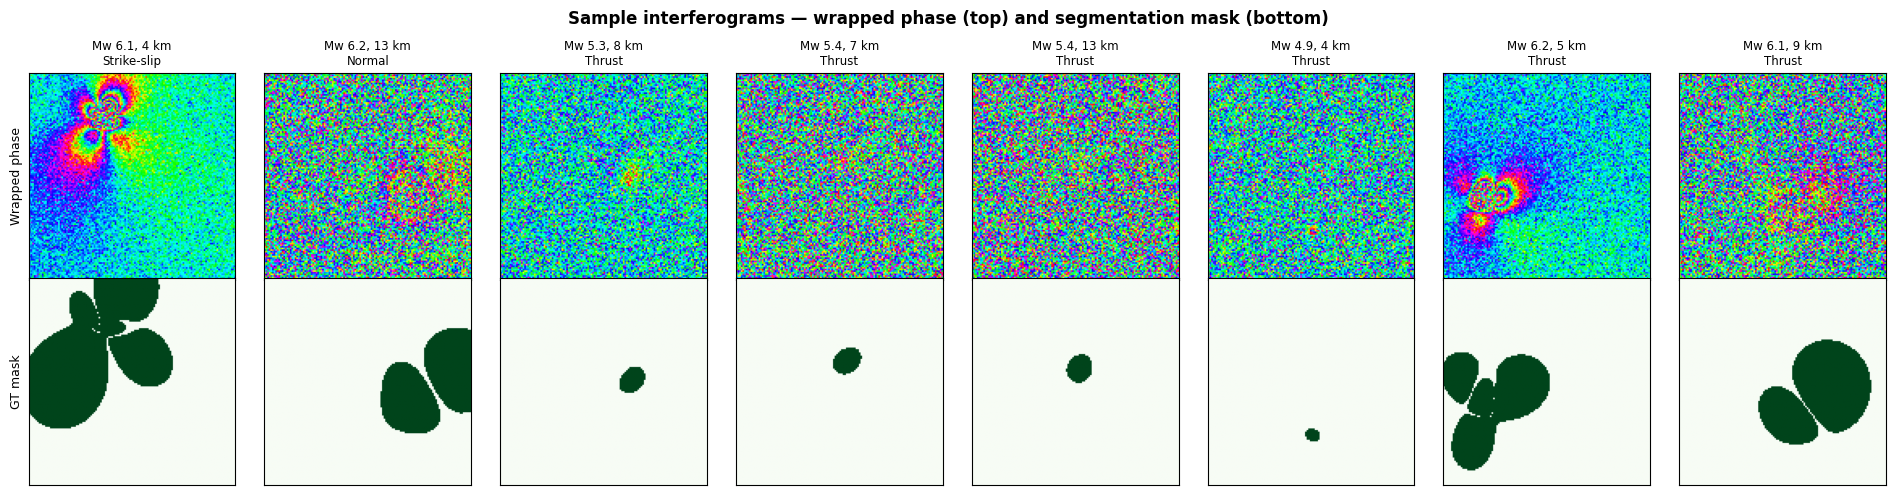

In [5]:
# Show 8 training samples: wrapped phase + ground-truth mask side by side
n_show = 8
rng_vis = np.random.default_rng(1)
show_idx = rng_vis.choice(N_TRAIN, n_show, replace=False)

fig, axes = plt.subplots(2, n_show, figsize=(2.4 * n_show, 5))
fig.suptitle('Sample interferograms — wrapped phase (top) and segmentation mask (bottom)',
             fontsize=12, fontweight='bold')

for col, gi in enumerate(train_idx[show_idx]):
    ph  = X_phase[gi]
    msk = y_all[gi]
    mw    = meta[gi]['Mw']
    depth = meta[gi]['depth']
    ft    = meta[gi]['fault']
    axes[0, col].imshow(ph,  cmap='hsv', vmin=-np.pi, vmax=np.pi, origin='lower')
    axes[1, col].imshow(msk, cmap='Greens', vmin=0, vmax=1, origin='lower')
    axes[0, col].set_title(f'Mw {mw:.1f}, {depth:.0f} km\n{ft}', fontsize=8.5)
    for row in range(2):
        axes[row, col].set_xticks([]); axes[row, col].set_yticks([])

axes[0, 0].set_ylabel('Wrapped phase', fontsize=9)
axes[1, 0].set_ylabel('GT mask', fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig1_gallery.png', dpi=150, bbox_inches='tight')
plt.show()


In [6]:
# ── Dataset ────────────────────────────────────────────────────────────────────
class InSARDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = torch.from_numpy(X[:, None])   # (N,1,H,W)
        self.y = torch.from_numpy(y[:, None])
        self.augment = augment

    def __len__(self): return len(self.X)

    def __getitem__(self, i):
        x, y = self.X[i].clone(), self.y[i].clone()
        if self.augment:
            if torch.rand(1).item() > 0.5: x = torch.flip(x, [-1]); y = torch.flip(y, [-1])
            if torch.rand(1).item() > 0.5: x = torch.flip(x, [-2]); y = torch.flip(y, [-2])
        return x, y

# ── U-Net ──────────────────────────────────────────────────────────────────────
FEATURES = (32, 64, 128, 256)

class ConvBlock(nn.Module):
    def __init__(self, cin, cout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(cin, cout, 3, padding=1), nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
            nn.Conv2d(cout, cout, 3, padding=1), nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)

class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = nn.ModuleList()
        self.dec = nn.ModuleList()
        self.pool = nn.MaxPool2d(2)
        prev = 1
        for f in FEATURES:
            self.enc.append(ConvBlock(prev, f)); prev = f
        self.bottleneck = ConvBlock(prev, prev * 2); prev = prev * 2
        for f in reversed(FEATURES):
            self.dec.append(nn.ConvTranspose2d(prev, f, 2, 2))
            self.dec.append(ConvBlock(f * 2, f)); prev = f
        self.head = nn.Conv2d(prev, 1, 1)

    def forward(self, x):
        skips = []
        for enc in self.enc:
            x = enc(x); skips.append(x); x = self.pool(x)
        x = self.bottleneck(x)
        for i in range(0, len(self.dec), 2):
            x = self.dec[i](x)
            s = skips[-(i//2+1)]
            if x.shape != s.shape:
                x = F.interpolate(x, size=s.shape[-2:])
            x = self.dec[i+1](torch.cat([s, x], 1))
        return self.head(x)

n_params = sum(p.numel() for p in UNet().parameters() if p.requires_grad)
print(f'U-Net: {n_params/1e6:.2f} M trainable parameters')


U-Net: 7.77 M trainable parameters


In [7]:
torch.manual_seed(SEED); np.random.seed(SEED)

model  = UNet().to(DEVICE)
opt    = torch.optim.Adam(model.parameters(), lr=LR)
sched  = CosineAnnealingLR(opt, T_max=MAX_EPOCHS)
scaler = torch.amp.GradScaler('cuda', enabled=USE_AMP)

NW = min(4, os.cpu_count() or 1) if DEVICE.type == 'cuda' else 0
PIN = DEVICE.type == 'cuda'
tr_ld = DataLoader(InSARDataset(X_train, y_train, augment=True),
                   BATCH_SIZE, shuffle=True, num_workers=NW, pin_memory=PIN,
                   persistent_workers=(NW > 0))
va_ld = DataLoader(InSARDataset(X_val,   y_val),
                   BATCH_SIZE, shuffle=False, num_workers=NW, pin_memory=PIN,
                   persistent_workers=(NW > 0))

history = {'tr_loss': [], 'va_iou': []}
best_val = 0.0; best_state = None; best_ep = 1; pat = 0

t_train = time.time()
for ep in range(1, MAX_EPOCHS + 1):
    # Train
    model.train(); tr_loss = n = 0
    for X, y in tr_ld:
        X, y = X.to(DEVICE), y.to(DEVICE)
        opt.zero_grad()
        with torch.amp.autocast('cuda', enabled=USE_AMP):
            loss = F.binary_cross_entropy_with_logits(model(X), y)
        scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        tr_loss += loss.item() * len(X); n += len(X)
    sched.step()

    # Validate
    model.eval(); va_iou = n_va = 0
    with torch.no_grad():
        for X, y in va_ld:
            X, y = X.to(DEVICE), y.to(DEVICE)
            with torch.amp.autocast('cuda', enabled=USE_AMP):
                prob = torch.sigmoid(model(X).float())[:, 0]
            t = y[:, 0]; p = (prob > 0.5).float(); eps = 1e-9
            tp = (p*t).sum((-2,-1)); fp = (p*(1-t)).sum((-2,-1))
            fn = ((1-p)*t).sum((-2,-1))
            va_iou += ((tp+eps)/(tp+fp+fn+eps)).sum().item(); n_va += len(X)

    tr_loss /= n; va_iou /= n_va
    history['tr_loss'].append(tr_loss)
    history['va_iou'].append(va_iou)

    if va_iou > best_val + MIN_DELTA:
        best_val = va_iou; best_ep = ep; pat = 0
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        pat += 1
        if pat >= PATIENCE:
            print(f'Early stop at epoch {ep}  (best: ep {best_ep}, val IoU {best_val:.3f})')
            break

    if ep % 5 == 0 or ep == 1:
        print(f'  ep {ep:3d}  loss={tr_loss:.4f}  val_IoU={va_iou:.3f}  '
              f'{"*best*" if va_iou == best_val else ""}')

print(f'Training done in {(time.time()-t_train)/60:.1f} min')

# Restore best checkpoint and save
model.load_state_dict(best_state)
pt_path = f'{OUT_DIR}/unet_phase.pt'
torch.save(best_state, pt_path)
print(f'Model saved to {pt_path}')


  ep   1  loss=0.4774  val_IoU=0.396  *best*
  ep   5  loss=0.2747  val_IoU=0.730  
  ep  10  loss=0.1988  val_IoU=0.744  
  ep  15  loss=0.1645  val_IoU=0.770  
  ep  20  loss=0.1425  val_IoU=0.769  
  ep  25  loss=0.1317  val_IoU=0.785  
Early stop at epoch 28  (best: ep 21, val IoU 0.793)
Training done in 2.1 min
Model saved to eq_insar_quickstart/unet_phase.pt


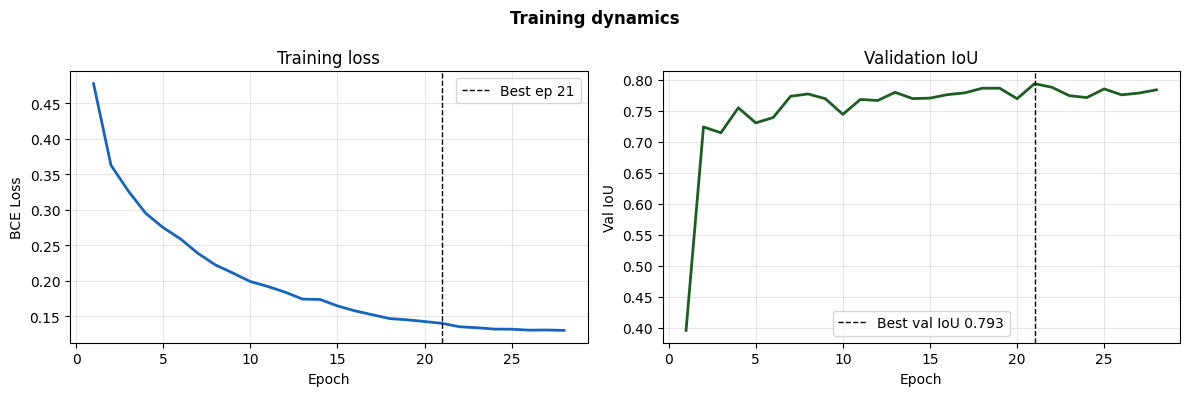

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Training dynamics', fontsize=12, fontweight='bold')
eps = range(1, len(history['tr_loss']) + 1)

ax1.plot(eps, history['tr_loss'], color='#1565C0', lw=2)
ax1.axvline(best_ep, color='k', ls='--', lw=1, label=f'Best ep {best_ep}')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('BCE Loss'); ax1.set_title('Training loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(eps, history['va_iou'], color='#1B5E20', lw=2)
ax2.axvline(best_ep, color='k', ls='--', lw=1, label=f'Best val IoU {best_val:.3f}')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Val IoU'); ax2.set_title('Validation IoU')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig2_training.png', dpi=150, bbox_inches='tight')
plt.show()


Test set results (N=200):
  IoU  = 0.773
  Dice = 0.830


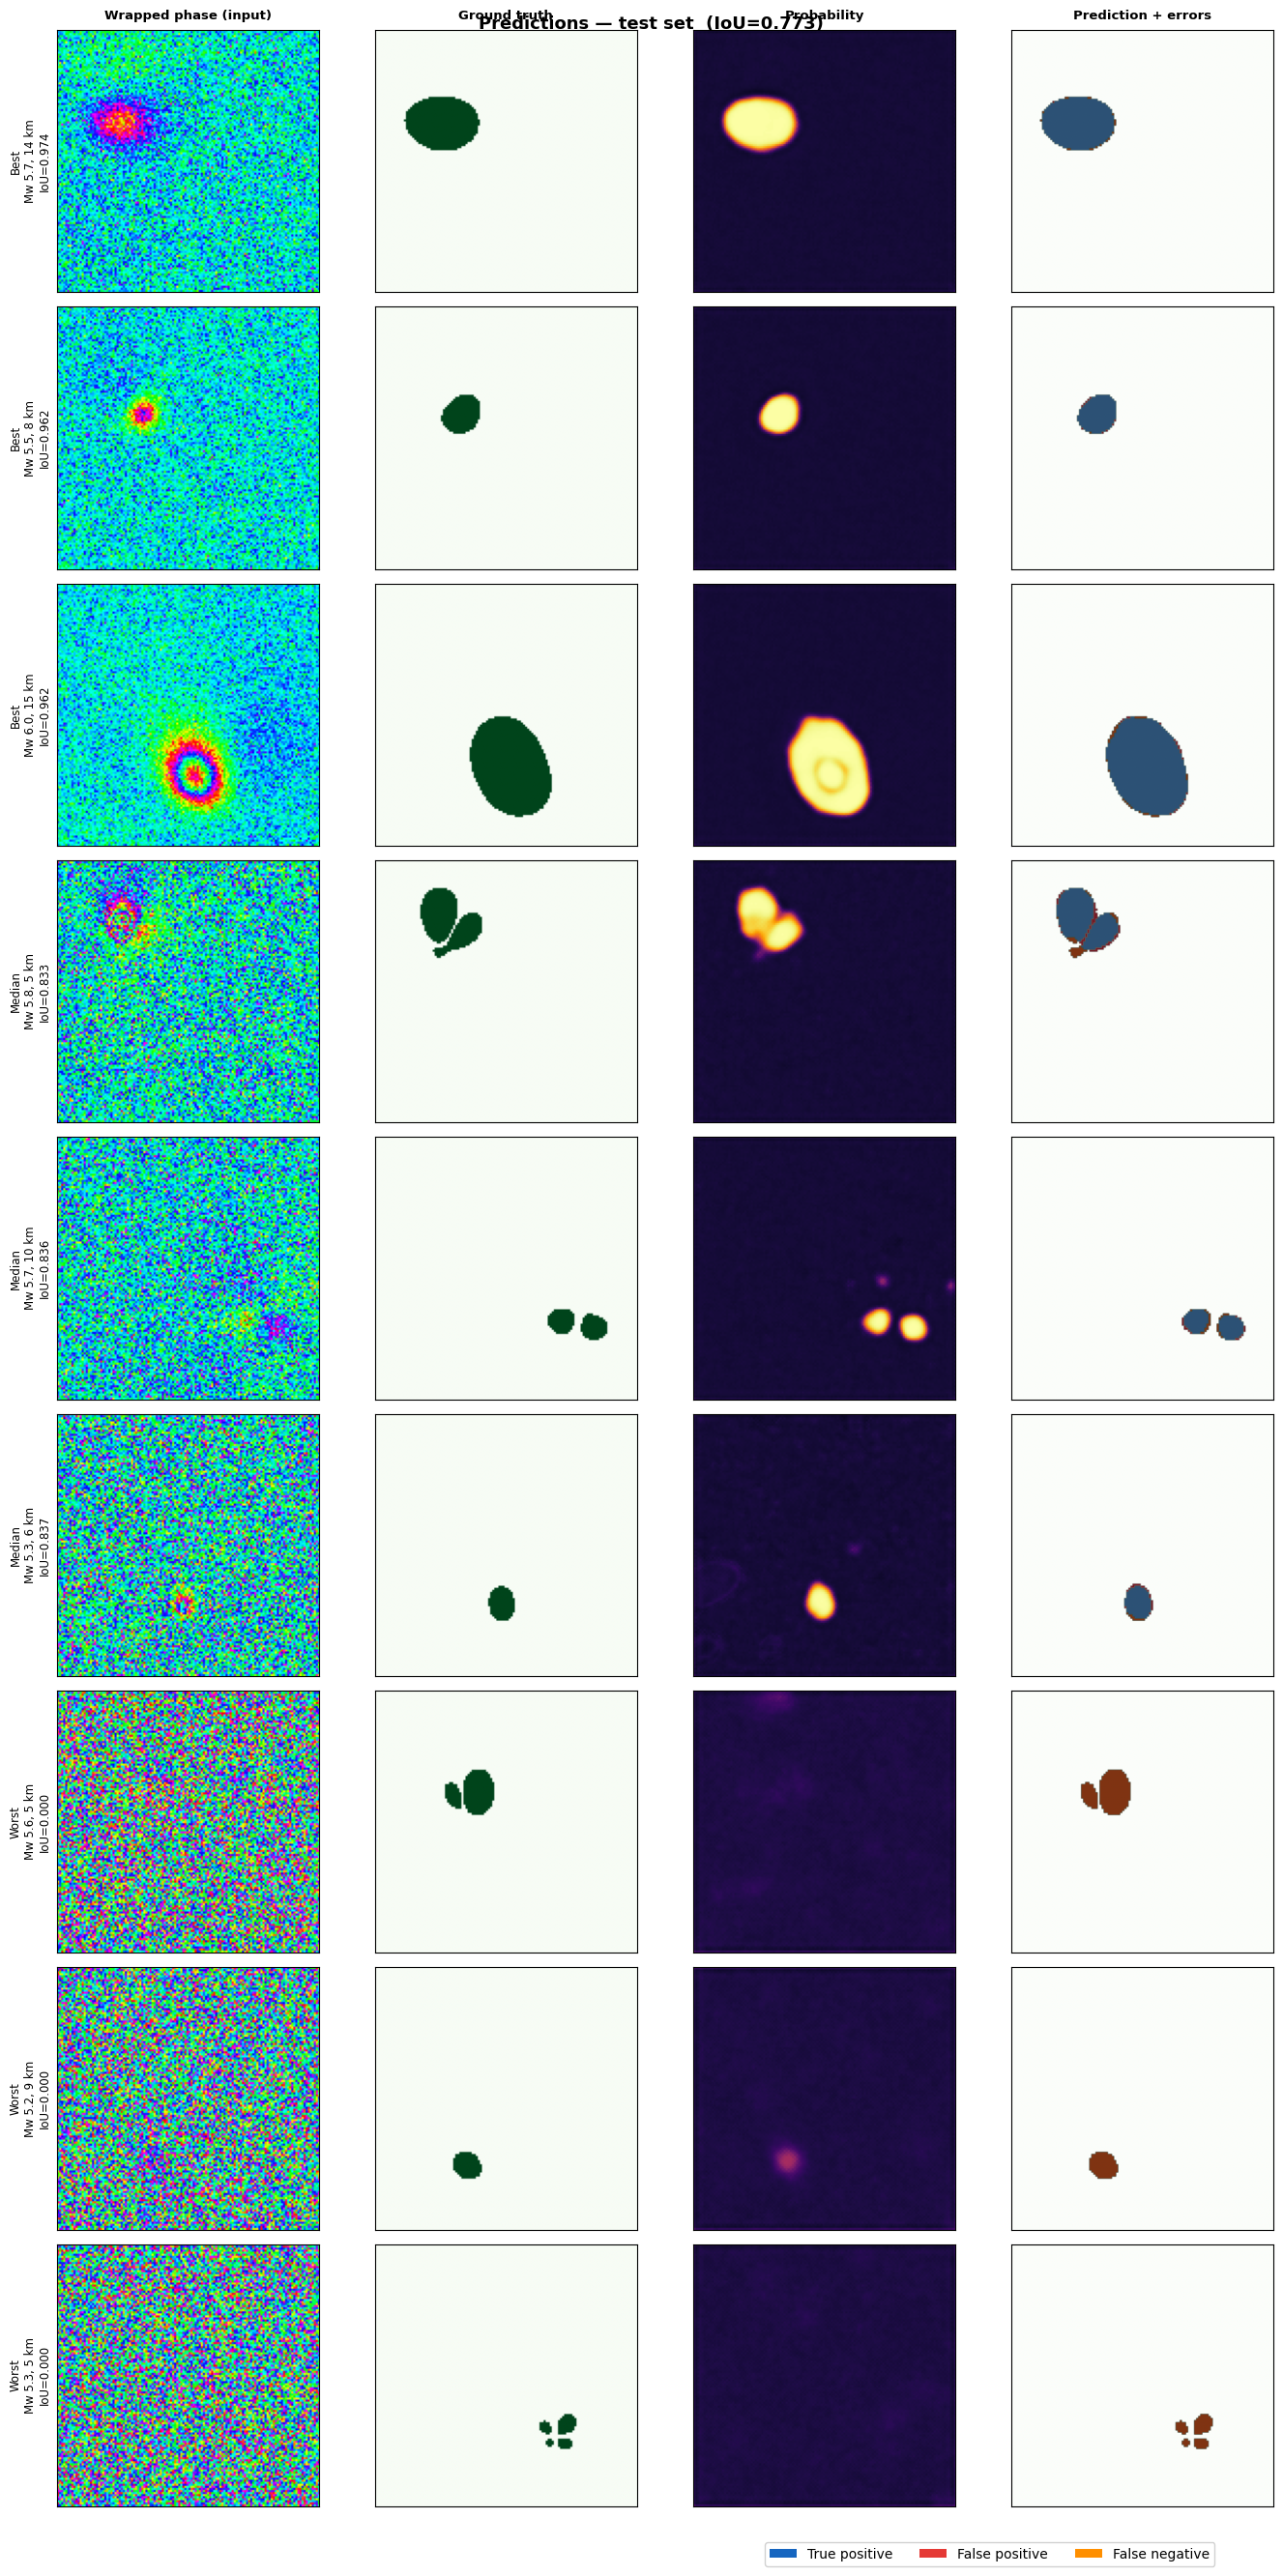

Predictions figure saved.


In [9]:
# ── Test set evaluation ────────────────────────────────────────────────────────
model.eval()
te_ld = DataLoader(InSARDataset(X_test, y_test), BATCH_SIZE, shuffle=False)
all_probs = []
with torch.no_grad():
    for X, y in te_ld:
        prob = torch.sigmoid(model(X.to(DEVICE)).float())[:, 0].cpu().numpy()
        all_probs.append(prob)
probs = np.concatenate(all_probs)   # (N_TEST, H, W)

eps = 1e-9
pred = (probs > 0.5).astype(float)
tp = (pred * y_test).sum((-2,-1)); fp = (pred * (1-y_test)).sum((-2,-1))
fn = ((1-pred) * y_test).sum((-2,-1))
iou_arr  = (tp+eps) / (tp+fp+fn+eps)
dice_arr = (2*tp+eps) / (2*tp+fp+fn+eps)

print(f'Test set results (N={N_TEST}):')
print(f'  IoU  = {iou_arr.mean():.3f}')
print(f'  Dice = {dice_arr.mean():.3f}')

# ── Qualitative predictions ────────────────────────────────────────────────────
pix = GRID_SZ * GRID_SZ
nonconstant = np.array([0 < y_test[i].sum() < pix for i in range(N_TEST)])
nc_idx = np.where(nonconstant)[0]
sorted_nc = nc_idx[np.argsort(iou_arr[nc_idx])]

show_idx = np.concatenate([sorted_nc[-3:][::-1],           # best 3
                            sorted_nc[len(sorted_nc)//2-1:len(sorted_nc)//2+2],  # median 3
                            sorted_nc[:3]])                  # worst 3
labels = ['Best'] * 3 + ['Median'] * 3 + ['Worst'] * 3

fig, axes = plt.subplots(9, 4, figsize=(14, 3 * 9))
fig.suptitle(f'Predictions — test set  (IoU={iou_arr.mean():.3f})',
             fontsize=13, fontweight='bold')

for j, title in enumerate(['Wrapped phase (input)', 'Ground truth', 'Probability', 'Prediction + errors']):
    axes[0, j].set_title(title, fontsize=9.5, fontweight='bold', pad=8)

for row, (idx_local, lbl) in enumerate(zip(show_idx, labels)):
    gi    = test_idx[idx_local]
    phase = X_phase[gi]
    gt    = y_test[idx_local]
    prob  = probs[idx_local]
    pred_m = (prob > 0.5).astype(float)
    iou_v   = iou_arr[idx_local]
    mw_v    = meta[gi]['Mw']
    depth_v = meta[gi]['depth']

    axes[row, 0].imshow(phase,  cmap='hsv', vmin=-np.pi, vmax=np.pi, origin='lower')
    axes[row, 1].imshow(gt,     cmap='Greens', vmin=0, vmax=1, origin='lower')
    axes[row, 2].imshow(prob,   cmap='inferno', vmin=0, vmax=1, origin='lower')

    fp_m = (pred_m == 1) & (gt == 0); fn_m = (pred_m == 0) & (gt == 1)
    tp_m = (pred_m == 1) & (gt == 1)
    axes[row, 3].imshow(gt,  cmap='Greens', vmin=0, vmax=1, alpha=0.5, origin='lower')
    axes[row, 3].imshow(np.ma.masked_where(~tp_m, np.ones_like(gt)),
                        cmap='Blues',   vmin=0, vmax=1, alpha=0.7, origin='lower')
    axes[row, 3].imshow(np.ma.masked_where(~fp_m, np.ones_like(gt)),
                        cmap='Reds',    vmin=0, vmax=1, alpha=0.9, origin='lower')
    axes[row, 3].imshow(np.ma.masked_where(~fn_m, np.ones_like(gt)),
                        cmap='Oranges', vmin=0, vmax=1, alpha=0.9, origin='lower')

    axes[row, 0].set_ylabel(f'{lbl}\nMw {mw_v:.1f}, {depth_v:.0f} km\nIoU={iou_v:.3f}', fontsize=8.5)
    for j in range(4):
        axes[row, j].set_xticks([]); axes[row, j].set_yticks([])

legend_handles = [
    mpatches.Patch(fc='#1565C0', label='True positive'),
    mpatches.Patch(fc='#E53935', label='False positive'),
    mpatches.Patch(fc='#FF8F00', label='False negative'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=3,
           fontsize=10, framealpha=0.9, bbox_to_anchor=(0.75, 0.0))
plt.tight_layout(rect=[0, 0.02, 1, 1])
plt.savefig(f'{FIG_DIR}/fig3_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Predictions figure saved.')


In [ ]:
# ── Apply the trained model to a new synthetic sample ─────────────────────────
# This is the same workflow you would use with real Sentinel-1 wrapped phase.

fresh = generate_synthetic_insar(
    Mw=5.8, strike_deg=120, dip_deg=40, rake_deg=90,   # Mw 5.8 thrust
    depth_km=8, xcen_km=5, ycen_km=-5,
    satellite='sentinel1', orbit='ascending',
    grid_size=GRID_SZ, noise_amplitude_m=0.004, noise_model='gaussian', seed=99_999,
)

phase_input = torch.from_numpy(
    (fresh['phase_noisy'] / np.pi).astype(np.float32)[None, None]
).to(DEVICE)   # (1, 1, H, W)  —  same normalisation as training

model.eval()
with torch.no_grad():
    prob  = torch.sigmoid(model(phase_input))[0, 0].cpu().numpy()
mask  = (prob > 0.5).astype(np.uint8)
gt_mask = (np.abs(fresh['los_displacement']) > LABEL_THR).astype(np.uint8)
eps = 1e-9
iou_fresh = float(((mask & gt_mask).sum() + eps) / ((mask | gt_mask).sum() + eps))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle(f'Inference on a fresh synthetic sample  (Mw 5.8 thrust, IoU={iou_fresh:.3f})',
             fontsize=12, fontweight='bold')
axes[0].imshow(fresh['phase_noisy'], cmap='hsv', vmin=-np.pi, vmax=np.pi, origin='lower')
axes[0].set_title('Wrapped phase (input)')
axes[1].imshow(gt_mask, cmap='Greens', vmin=0, vmax=1, origin='lower')
axes[1].set_title('Ground truth')
axes[2].imshow(prob, cmap='inferno', vmin=0, vmax=1, origin='lower')
axes[2].set_title('Predicted probability')
axes[3].imshow(mask, cmap='Blues', vmin=0, vmax=1, origin='lower')
axes[3].set_title(f'Predicted mask  (IoU={iou_fresh:.3f})')
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig4_inference.png', dpi=150, bbox_inches='tight')
plt.show()


In [11]:
elapsed = time.time() - T_START
print(f'Total elapsed: {elapsed/60:.1f} min')
print(f'Test IoU: {iou_arr.mean():.3f}   Dice: {dice_arr.mean():.3f}')
print(f'Model saved to: {OUT_DIR}/unet_phase.pt')
print(f'Figures saved to: {FIG_DIR}/')


Total elapsed: 2.6 min
Test IoU: 0.773   Dice: 0.830
Model saved to: eq_insar_quickstart/unet_phase.pt
Figures saved to: eq_insar_quickstart/figures/


## Next steps

### Use a different satellite or orbit
```python
from eq_insar import generate_synthetic_insar
r = generate_synthetic_insar(..., satellite='sentinel1', orbit='descending')
r = generate_synthetic_insar(..., satellite='alos2')   # L-band
```

### Generate a larger dataset for better accuracy
Change `TOTAL = 8_000` and retrain. See the full benchmark notebook
([`InSAR_Earthquake_Segmentation_PyTorch_v3.ipynb`](InSAR_Earthquake_Segmentation_PyTorch_v3.ipynb))
for results with 8 000 samples and 5 independent seeds (test IoU 0.797).

### Apply to real Sentinel-1 data
Load your wrapped phase as a NumPy array (radians), crop to the area of interest,
resize to `128×128` px, then:
```python
phase_input = torch.from_numpy((your_phase / np.pi).astype(np.float32)[None, None])
with torch.no_grad():
    prob = torch.sigmoid(model(phase_input.to(DEVICE)))[0, 0].cpu().numpy()
mask = (prob > 0.5).astype(np.uint8)
```
No additional pre-processing is needed — the model is trained on the same
wrapped-phase representation that Sentinel-1 products deliver.

### Mix synthetic and real data for domain adaptation
A model trained purely on synthetic data may not generalise perfectly to real
interferograms due to atmospheric noise, orbital ramps, and DEM errors not
captured by the simulator. If you have even a small set of labelled real events
(tens of interferograms), mixing them with the synthetic dataset during training
is a straightforward way to bridge the domain gap:
```python
# Combine synthetic and real samples before splitting
X_combined = np.concatenate([X_synthetic, X_real], axis=0)
y_combined = np.concatenate([y_synthetic, y_real], axis=0)
```
EQ-INSAR controls noise amplitude, orbital ramp magnitude, and satellite
geometry — tuning these to match your real data statistics narrows the gap
further before any real labels are needed.

### Fine-tune on real data after synthetic pre-training
Alternatively, use the synthetically pre-trained model as a starting point and
fine-tune with a low learning rate on your real labelled set:
```python
model.load_state_dict(torch.load('unet_phase.pt'))
opt = torch.optim.Adam(model.parameters(), lr=1e-5)   # lower LR for fine-tuning
```
Even a handful of real events (5–20) can meaningfully improve performance on
real data when the model has already learned the task structure from synthetic data.

### Citation
```bibtex
@misc{cieslik2026eqinsar,
  author = {Cieslik, Konrad and Milczarek, Wojciech},
  title  = {EQ-INSAR: A Python Package for Generating Synthetic Earthquake InSAR Deformation Data},
  year   = {2026},
  doi    = {10.5281/zenodo.18647190},
  url    = {https://github.com/kcieslik/eq-insar}
}
```
